[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NguyenVu04/band-tilt/blob/main/notebooks/00_simulation.ipynb)

# 00 — The Synthetic Network

**Question.** Which network, users and measurements does the study run on?

**Inputs.** `configs/simulation.yaml`.
**Outputs.** `data/external/` (UE positions, scenario manifest) and `data/interim/` (radio map, synthetic MDT).
**Requirements.** A CUDA GPU for Sionna-RT ray tracing. The shell equivalent is `task simulation`.

In [1]:
# Environment: locally, move to the project root; on Colab, clone the repository
# and install what Colab lacks. Extra Hydra overrides come from BAND_TILT_OVERRIDES.
REPO_URL = "https://github.com/NguyenVu04/band-tilt.git"
COLAB_PACKAGES = [("hydra", "hydra-core"), ("sionna.rt", "sionna-rt")]

import importlib.util
import os
import subprocess
import sys
from pathlib import Path

try:
    import google.colab  # noqa: F401

    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    root = Path("/content/band-tilt")
    if not root.exists():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(root)], check=True)
    missing = [pip for module, pip in COLAB_PACKAGES if importlib.util.find_spec(module) is None]
    if missing:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *missing], check=True)
else:
    root = Path.cwd()
    while not (root / "pyproject.toml").exists() and root != root.parent:
        root = root.parent

os.chdir(root)
sys.path.insert(0, str(root))
CONFIG_OVERRIDES = os.environ.get("BAND_TILT_OVERRIDES", "").split()

In [2]:
%load_ext autoreload
%autoreload 2

import json
from functools import partial

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.config import load_config
from src.evaluation.export import save_table
from src.utils.plotting import label, save_fig, setup_plotting
from src.utils.seed import set_seed

cfg = load_config(overrides=CONFIG_OVERRIDES)
set_seed(cfg.seed)
setup_plotting()
save_fig = partial(save_fig, in_colab=IN_COLAB, directory=Path("reports/figures/00_simulation"))
save_table = partial(save_table, in_colab=IN_COLAB, directory=Path("reports/tables/00_simulation"))
pd.set_option("display.precision", 4)
pd.set_option("display.max_columns", 40)

## 1. Nodes and Frequency Bands

Every node carries three sectors, and every sector serves the same three frequency bands.
Each (cell, band) pair has its own antenna tilt, which is the decision variable of the study.

In [3]:
from src.simulation import transmitter

cells = transmitter.load(cfg)
bands = [str(entry.name) for entry in cfg.simulation.radio_map.bands]
nodes = pd.DataFrame({"x": [cell.x for cell in cells], "y": [cell.y for cell in cells]})


def tilt_text(tilt):
    """Current tilt with its allowed range, e.g. ``10 (0 to 10)``."""
    low, high = tilt.bounds_deg
    return f"{tilt.baseline_deg:g} ({low:g} to {high:g})"


layout = pd.DataFrame(
    [
        {
            "Node": cell.name.rsplit("c", 1)[0],
            "Cell": cell.name,
            "x [m]": cell.x,
            "y [m]": cell.y,
            "Antenna height [m]": cell.z,
            "Azimuth [°]": cell.azimuth_deg,
            **{
                f"{label(band)} tilt [°] (allowed range)": tilt_text(cell.tilt_for(band))
                for band in bands
            },
        }
        for cell in cells
    ]
)
save_table(layout, "node_layout")
layout

,Node,Cell,x [m],y [m],Antenna height [m],Azimuth [°],2600 MHz tilt [°] (allowed range),1800 MHz tilt [°] (allowed range),700 MHz tilt [°] (allowed range)
0,n0,n0c0,-4.12,107.16,25.0,30.0,5 (0 to 15),5 (0 to 15),5 (0 to 15)
1,n0,n0c1,-4.12,107.16,25.0,150.0,5 (0 to 15),5 (0 to 15),5 (0 to 15)
2,n0,n0c2,-4.12,107.16,25.0,270.0,5 (0 to 15),5 (0 to 15),5 (0 to 15)
3,n1,n1c0,-241.19,-309.00,25.0,30.0,5 (0 to 15),5 (0 to 15),5 (0 to 15)
4,n1,n1c1,-241.19,-309.00,25.0,150.0,5 (0 to 15),5 (0 to 15),5 (0 to 15)
5,n1,n1c2,-241.19,-309.00,25.0,270.0,5 (0 to 15),5 (0 to 15),5 (0 to 15)
6,n2,n2c0,315.92,-350.56,25.0,30.0,5 (0 to 15),5 (0 to 15),5 (0 to 15)
7,n2,n2c1,315.92,-350.56,25.0,150.0,5 (0 to 15),5 (0 to 15),5 (0 to 15)
8,n2,n2c2,315.92,-350.56,25.0,270.0,5 (0 to 15),5 (0 to 15),5 (0 to 15)


In [4]:
carriers = pd.DataFrame(
    [
        {
            "Band": label(entry.name),
            "Carrier frequency [MHz]": float(entry.frequency) / 1e6,
            "Bandwidth [MHz]": float(entry.bandwidth) / 1e6,
            "PRB limit per cell": ", ".join(
                str(limit) for limit in sorted({cell.max_prb_for(entry.name) for cell in cells})
            ),
        }
        for entry in cfg.simulation.radio_map.bands
    ]
)
save_table(carriers, "frequency_bands")
carriers

,Band,Carrier frequency [MHz],Bandwidth [MHz],PRB limit per cell
0,2600 MHz,2600.0,40.0,216
1,1800 MHz,1800.0,20.0,106
2,700 MHz,700.0,10.0,52


**Observations.** _To be written._

## 2. Users and Traffic

The scenario fixes the city and the user population once, so that every later change in a KPI
is caused by tilt alone. Users are drawn each interval from demand hotspots and a uniform background.

In [5]:
from src.simulation import scenario

ue_file, manifest_file = scenario.generate(cfg)
manifest = json.loads(Path(manifest_file).read_text(encoding="utf-8"))
ue = pd.read_csv(ue_file)

scenario_summary = (
    pd.DataFrame(
        {
            "Value": {
                "Scenario ID": manifest["scenario_id"],
                "Grid [tiles]": f"{manifest['grid']['n_rows']} x {manifest['grid']['n_cols']}",
                "Tile size [m]": manifest["grid"]["tile_size_m"],
                "Time intervals": manifest["time"]["n_intervals"],
                "Interval length [min]": float(cfg.simulation.time.interval_s) / 60,
                "Demand hotspots": len(manifest["density"]["hotspots"]),
                "UE positions drawn": len(ue),
            }
        }
    )
    .rename_axis("Property")
    .reset_index()
)
save_table(scenario_summary, "scenario_summary")
scenario_summary

jitc_llvm_init(): LLVM API initialization failed ..


scenario: scn_28d06a5bfb4c02e6
grid:     74 x 61 tiles, 4333 eligible
hotspots: 4
time:     672 intervals of 900 s, 10-20 UEs each
demand:   hotspots hold 78% to 95% of the population across intervals
ue:       10066 rows at z=1.5 m
densest decile holds 58.0% of UEs
csv:      data\external\ue_positions.csv
manifest: data\external\scenario.json


,Property,Value
0,Scenario ID,scn_28d06a5bfb4c02e6
1,Grid [tiles],61 x 74
2,Tile size [m],20.0
3,Time intervals,672
4,Interval length [min],15.0
5,Demand hotspots,4
6,UE positions drawn,10066


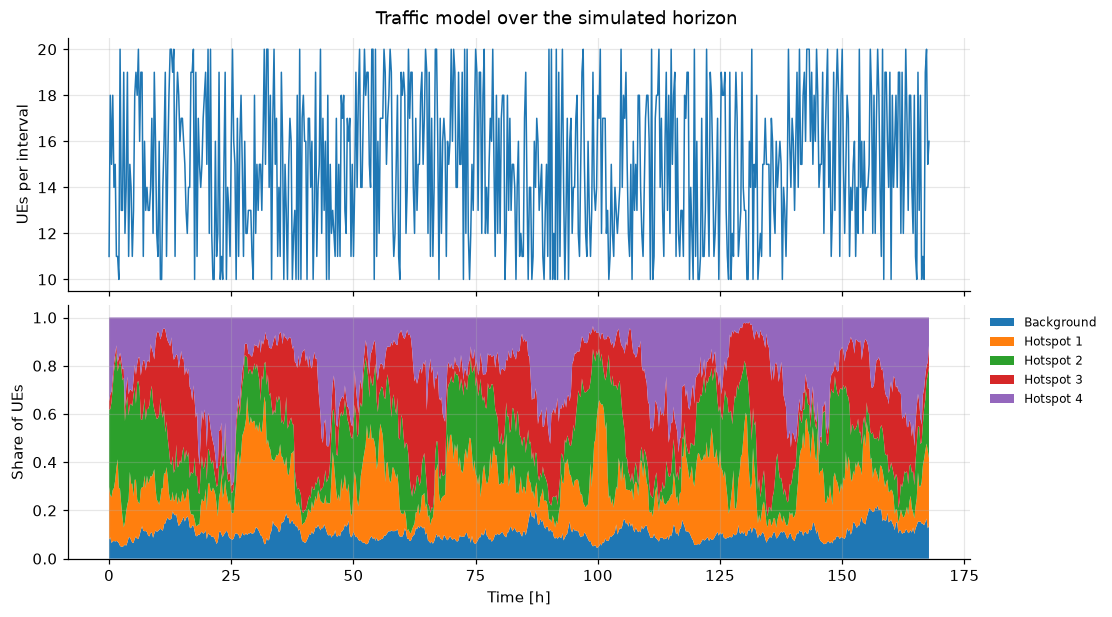

In [6]:
hours = np.asarray(manifest["time"]["t_s"]) / 3600.0
mass = np.asarray(manifest["time"]["component_mass"])

figure, axes = plt.subplots(2, 1, figsize=(10.0, 5.5), sharex=True, constrained_layout=True)
axes[0].plot(hours, manifest["time"]["count"], lw=1.0)
axes[0].set_ylabel("UEs per interval")
axes[1].stackplot(
    hours,
    mass.T,
    labels=["Background"] + [f"Hotspot {index + 1}" for index in range(mass.shape[1] - 1)],
)
axes[1].set(xlabel="Time [h]", ylabel="Share of UEs")
axes[1].legend(loc="upper left", bbox_to_anchor=(1.01, 1.0), fontsize=8)
figure.suptitle("Traffic model over the simulated horizon")
save_fig(figure, "traffic_model")
plt.show()

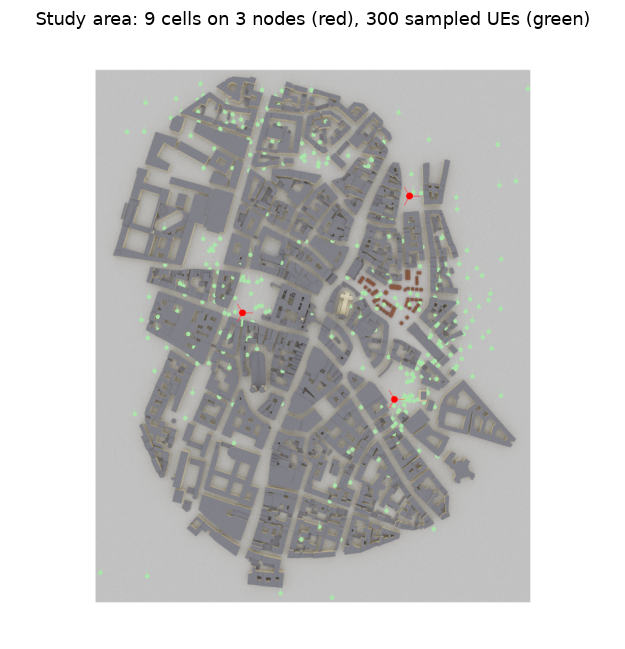

In [7]:
from sionna.rt import Receiver

from src.simulation import scene as scene_module

UE_RENDER_SAMPLE = 300

scene, bounds = scene_module.load(scene_module.SceneSpec.from_config(cfg))
transmitter.build(scene, cells, bands[0], float(cfg.simulation.antenna.power_rs))
sample = ue.sample(n=min(UE_RENDER_SAMPLE, len(ue)), random_state=cfg.seed)
for index, row in enumerate(sample.itertuples()):
    scene.add(Receiver(name=f"ue{index}", position=[row.x, row.y, row.z], display_radius=6.0))

n_nodes = len({(cell.x, cell.y) for cell in cells})
figure = scene_module.render_top_down(
    scene,
    bounds,
    f"Study area: {len(cells)} cells on {n_nodes} nodes (red), {len(sample)} sampled UEs (green)",
    show_devices=True,
    show_orientations=True,
)
save_fig(figure, "study_area")
plt.show()
del scene

**Observations.** _To be written._

## 3. Radio Map

Sionna-RT traces rays from every cell on every band over the measurement grid, at the configured
baseline tilts. The result is the ground truth every KPI is computed from.

   b2600  tilt  5.0- 5.0 deg     1.1s  tiles reached  82.6%  best server -209.6 to  -55.6 dBm
   b1800  tilt  5.0- 5.0 deg     0.8s  tiles reached  81.8%  best server -177.3 to  -54.9 dBm
    b700  tilt  5.0- 5.0 deg     0.7s  tiles reached  84.1%  best server -193.5 to  -45.4 dBm
radio map: data\interim\radio_map.npz  shape (3, 9, 61, 74) [band, tx, row, col]


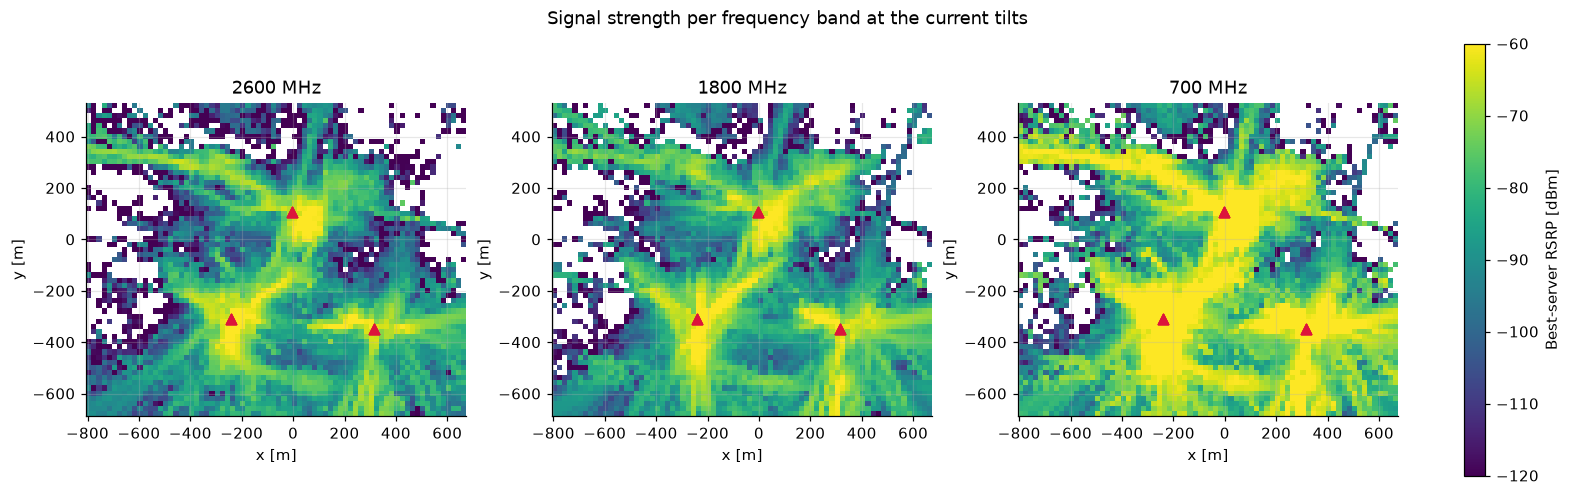

In [8]:
from src.evaluation import maps, plots
from src.kpi.capacity import max_rsrp
from src.simulation import radio

radio_map_file = radio.solve(cfg)
with np.load(radio_map_file, allow_pickle=False) as archive:
    radio_map = {key: archive[key] for key in archive.files}
rsrp = radio_map["rsrp_dbm"].astype(float)
best_per_band = {band: max_rsrp(rsrp[[index]]) for index, band in enumerate(bands)}

figure = plots.map_row(
    {label(band): best for band, best in best_per_band.items()},
    radio_map,
    colorbar_label="Best-server RSRP [dBm]",
    vmin=maps.RSRP_LIMITS[0],
    vmax=maps.RSRP_LIMITS[1],
    cells=nodes,
)
figure.suptitle("Signal strength per frequency band at the current tilts")
save_fig(figure, "rsrp_per_band")
plt.show()

In [9]:
reach = pd.DataFrame(
    [
        {
            "Band": label(band),
            "Tiles reached [%]": 100.0 * np.isfinite(best).mean(),
            "Median RSRP of reached tiles [dBm]": float(np.median(best[np.isfinite(best)])),
        }
        for band, best in best_per_band.items()
    ]
)
save_table(reach, "reach_per_band")
reach

,Band,Tiles reached [%],Median RSRP of reached tiles [dBm]
0,2600 MHz,82.6318,-88.1106
1,1800 MHz,81.8121,-84.2918
2,700 MHz,84.0718,-74.5975


**Observations.** _To be written._

## 4. Synthetic MDT

Minimization of Drive Tests (MDT) reports are what handsets would measure: the radio map sampled at
each UE position, plus receiver measurement error. UEs no cell reaches report nothing and are dropped.

ue:        9202 rows x 27 cell-bands of RSRP (864 no-signal UEs dropped)
intervals: 672, 14 UEs per interval on average
reachable:  57.5% of measurements had a path
per ue:    1 to 27 cells reported
mdt:       data\interim\mdt.csv


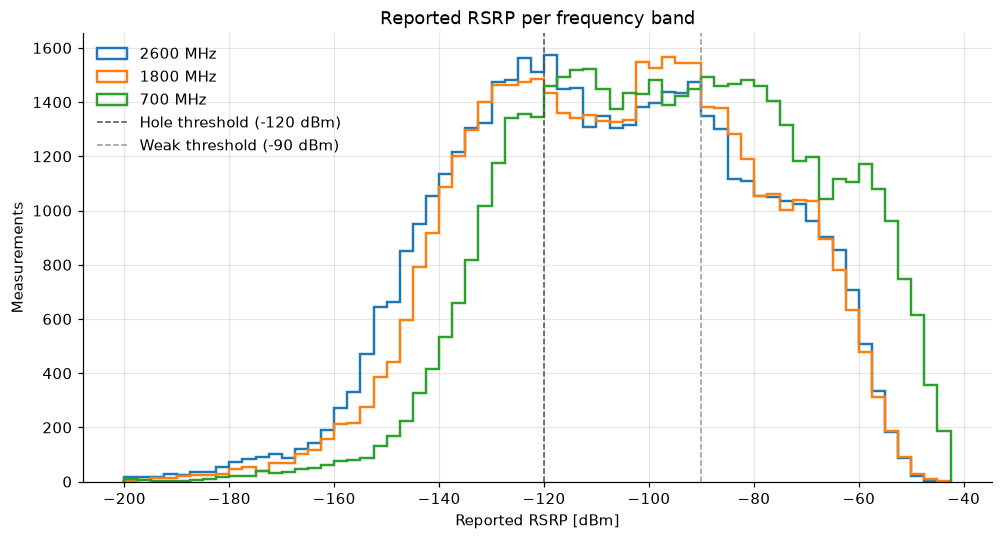

,Property,Value
0,UE reports,9202.0
1,UEs dropped (no cell reached),864.0
2,Cell-band measurement columns,27.0
3,"Measurement error, standard deviation [dB]",4.0


In [10]:
from src.simulation import mdt

mdt_file = mdt.build(cfg)
mdt_frame = pd.read_csv(mdt_file)
hole_dbm, weak_dbm = float(cfg.kpi.hole_dbm), float(cfg.kpi.weak_dbm)

figure, axis = plt.subplots(figsize=(9.0, 4.8), constrained_layout=True)
edges = np.arange(-200.0, -40.0, 2.5)
for band in bands:
    columns = [c for c in mdt_frame.columns if c.startswith("rsrp_") and c.endswith(f"_{band}")]
    values = mdt_frame[columns].to_numpy().ravel()
    axis.hist(values[np.isfinite(values)], bins=edges, histtype="step", lw=1.6, label=label(band))
axis.axvline(hole_dbm, color="0.3", ls="--", lw=1, label=f"Hole threshold ({hole_dbm:g} dBm)")
axis.axvline(weak_dbm, color="0.6", ls="--", lw=1, label=f"Weak threshold ({weak_dbm:g} dBm)")
axis.set(
    xlabel="Reported RSRP [dBm]", ylabel="Measurements", title="Reported RSRP per frequency band"
)
axis.legend()
save_fig(figure, "mdt_rsrp_distribution")
plt.show()

mdt_summary = (
    pd.DataFrame(
        {
            "Value": {
                "UE reports": len(mdt_frame),
                "UEs dropped (no cell reached)": len(ue) - len(mdt_frame),
                "Cell-band measurement columns": sum(
                    c.startswith("rsrp_") for c in mdt_frame.columns
                ),
                "Measurement error, standard deviation [dB]": float(
                    cfg.simulation.mdt.rsrp_noise_sigma_db
                ),
            }
        }
    )
    .rename_axis("Property")
    .reset_index()
)
save_table(mdt_summary, "mdt_summary")
mdt_summary

**Observations.** _To be written._